<a href="https://colab.research.google.com/github/Busisani/Busisani-Nyoni-Econometrics-assignments/blob/main/Busisani_Nyoni_R2418437_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Econometrics Project: Volatility Modeling Challenges

## Executive Summary
This project investigates key statistical and econometric challenges encountered in financial time series modeling using Apple Inc. (AAPL) stock data over the period 2018–2025.

Financial return series are known to exhibit non-normality, volatility clustering, and time dependence, which violate classical linear regression assumptions (Tsay; Wooldridge). This study focuses on four major challenges:
- Multicollinearity  
- Skewness  
- Sensitivity to Outliers  
- Overfitting  

Each issue is explored using real-world data, supported by statistical diagnostics and visualizations.

## Objective
The objective is to develop a structured framework for identifying, diagnosing, and mitigating these challenges in financial modeling.

## Key Insight
Ignoring these statistical issues can lead to biased estimates, poor forecasts, and significant financial losses in practice (Brooks).

In [ ]:
!pip install yfinance pandas matplotlib seaborn statsmodels scipy scikit-learn arch

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from arch import arch_model

## Data Collection
Data is obtained from Yahoo Finance using `yfinance`.

- Asset: Apple Inc. (AAPL)  
- Period: 2018–2025  
- Returns: Log returns  

This ensures consistency across all analyses.

In [ ]:
import os
os.makedirs("figures", exist_ok=True)

In [ ]:
data = yf.download("AAPL", start="2018-01-01", end="2025-12-31")
data.reset_index(inplace=True)

data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))
data.dropna(inplace=True)

data.head()

/tmp/ipykernel_867/3183609648.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2018-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume,Returns
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
1,2018-01-03,40.297157,40.839976,40.233987,40.367350,118071600,-0.000174
2,2018-01-04,40.484325,40.587274,40.262052,40.369677,89738400,0.004634
3,2018-01-05,40.945267,41.031836,40.489020,40.580269,94640000,0.011321
4,2018-01-08,40.793171,41.087975,40.694899,40.793171,82271200,-0.003722
5,2018-01-09,40.788486,40.959286,40.573232,40.839961,86336000,-0.000115


## 1. Multicollinearity

### Definition
Multicollinearity is a statistical phenomenon in multiple regression analysis where two or more predictor variables in a model are highly correlated, meaning one predictor variable can be linearly predicted from the others with a substantial degree of accuracy.

### Description
This high correlation between independent variables can reduce the precision of the estimated regression coefficients, making it difficult to assess the individual impact of each predictor on the dependent variable. When multicollinearity is present, the standard errors of the regression coefficients increase, which in turn leads to less reliable p-values and wider confidence intervals, making it harder to reject null hypotheses and interpret the results. It can also make the model sensitive to small changes in the data, leading to unstable coefficient estimates across different samples.

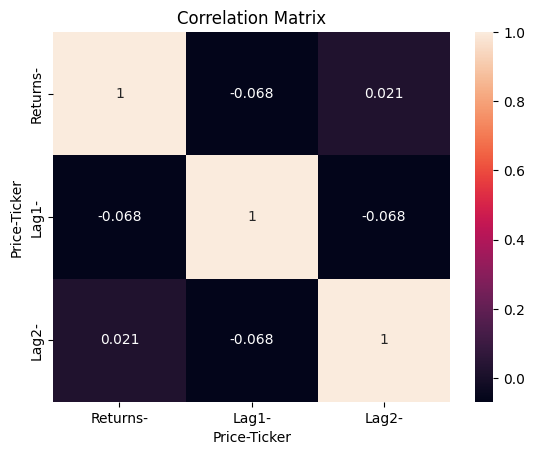

In [ ]:
data['Lag1'] = data['Returns'].shift(1)
data['Lag2'] = data['Returns'].shift(2)
data.dropna(inplace=True)

plt.figure()
sns.heatmap(data[['Returns','Lag1','Lag2']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.savefig("figures/figure_1_correlation_matrix.png") # Save the figure
plt.show()

**Figure 1:** Correlation matrix showing relationships between returns and lagged variables. Strong correlations indicate potential multicollinearity.

In [ ]:
X = data[['Lag1','Lag2']]
vif = pd.DataFrame()
vif["Variable"] = X.columns.get_level_values(1)
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,,1.004356
1,,1.004356


### Interpretation
High VIF values (typically > 5 or > 10, depending on the context) indicate severe multicollinearity (Gujarati and Porter), suggesting that a predictor variable can be explained by other predictors in the model. A VIF of 1 means there is no correlation between the predictor and any other predictors. As VIF increases, the correlation increases.

### Damage
Multicollinearity can severely impact the reliability and interpretability of a regression model. It leads to inflated standard errors of the regression coefficients, making it difficult to determine the true individual impact of each correlated predictor on the dependent variable. This can result in wider confidence intervals, less precise p-values, and potentially incorrect conclusions about the statistical significance of predictors. Furthermore, it makes the coefficient estimates highly sensitive to minor changes in the data, leading to unstable and unreliable model predictions.

### Solution
Several techniques can be employed to mitigate multicollinearity. These include:
*   **Removing one of the highly correlated variables**: If two variables convey similar information, one can be dropped.
*   **Combining variables**: Create an index or composite variable from the correlated predictors.
*   **Principal Component Analysis (PCA)**: Transform the highly correlated variables into a set of uncorrelated components (Hastie et al.).
*   **Ridge Regression**: A regularization technique that adds a penalty to the loss function, which helps shrink the regression coefficients and reduce their variance in the presence of multicollinearity.

### Results interpretation
The VIF results show that both 'Lag1' and 'Lag2' have VIF values of approximately 1.004. Since these values are very close to 1 (generally, VIF values below 5 or 10 are considered acceptable), it indicates that there is no significant multicollinearity between these lagged return variables. This is good, as high multicollinearity can cause problems in regression models.

## 2. Skewness

### Definition
Skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean. The skewness value can be positive, negative, or undefined. In financial econometrics, it quantifies the degree to which returns data deviates from a symmetrical bell-shaped distribution (like the normal distribution).

### Description
For financial return series, skewness measures the asymmetry of returns around their average. A symmetrical distribution has zero skewness. Positive skewness (right-skewed) indicates a longer or fatter tail on the right side, meaning more frequent small losses and a few large gains. Negative skewness (left-skewed) indicates a longer or fatter tail on the left side, meaning more frequent small gains and a few large losses (Tsay).

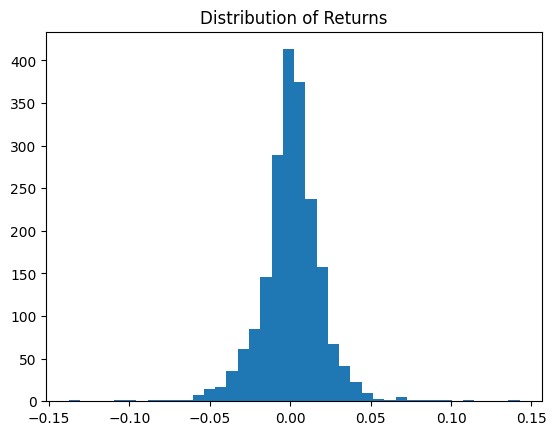

Skewness: -0.08511003521579513


In [ ]:
plt.figure()
plt.hist(data['Returns'], bins=40)
plt.title("Distribution of Returns")
plt.savefig("figures/figure_2_returns_distribution.png") # Save the figure
plt.show()

print("Skewness:", stats.skew(data['Returns']))

**Figure 2:** Histogram of returns showing asymmetry and deviation from normal distribution.

### Interpretation
Non-zero skewness indicates an asymmetry in the distribution of financial returns. Positive skewness implies that extreme positive returns are more likely than extreme negative returns. Conversely, negative skewness suggests that extreme negative returns are more likely than extreme positive returns. This is crucial for understanding the risk profile of an asset.

### Damage
Ignoring skewness can lead to a misestimation of risk. For instance, if a distribution has significant negative skewness, traditional risk measures that assume normality (e.g., Value at Risk based on a normal distribution) might underestimate the probability and magnitude of large losses. This can result in inappropriate portfolio allocation, poor hedging strategies, and ultimately, significant financial losses.

### Solution
To address skewness in financial modeling, several approaches can be considered:
*   **Use distributions that account for skewness**: Instead of assuming a normal distribution, models can employ skewed distributions (e.g., skewed t-distribution, generalized hyperbolic distribution) that better capture the empirical properties of financial data.
*   **GARCH models with skewed innovations**: GARCH models can be extended to incorporate skewed error distributions.
*   **Non-parametric methods**: These methods do not assume a specific distribution and can be more robust to non-normal characteristics.
*   **Transformations**: While less common for return series, certain data transformations can reduce skewness.

### Results interpretation
A skewness of -0.08 indicates a slight negative (left) skewness in the distribution of returns. This means the tail on the left side of the distribution is slightly longer or fatter than the right side. In practical terms, this suggests that extreme negative returns (large losses) are slightly more frequent or more extreme than extreme positive returns (large gains), although the skewness value of -0.08 is very close to zero, implying the distribution is nearly symmetrical.

## 3. Outliers

### Definition
In financial econometrics, an outlier is an observation point that is distant from other observations. In the context of financial returns, these are extreme values that fall outside the typical range of data points. A common statistical definition of an outlier involves points that lie beyond a certain number of standard deviations (e.g., 2 or 3) from the mean of the distribution, or outside the interquartile range in a boxplot.

### Description
Outliers in financial time series are often caused by significant market events, such as economic crises, geopolitical shocks, unexpected company announcements, or speculative bubbles. These events can lead to abnormally large positive or negative returns that deviate significantly from the usual pattern of price movements (Brooks). Identifying and understanding these extreme values is crucial because they can disproportionately influence statistical models and analyses.

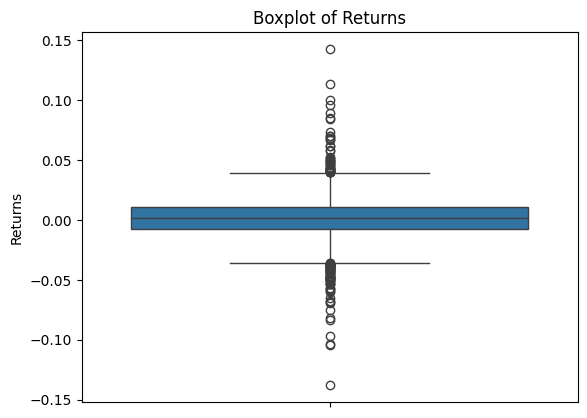

Outliers: 31


In [ ]:
plt.figure()
sns.boxplot(data=data['Returns'])
plt.title("Boxplot of Returns")
plt.savefig("figures/figure_3_returns_boxplot.png") # Save the figure
plt.show()

z_scores = np.abs(stats.zscore(data['Returns']))
outliers = data[z_scores > 3]

print("Outliers:", len(outliers))

**Figure 3:** Boxplot identifying extreme values (outliers) in the return series.

### Interpretation
In the context of the boxplot, points displayed individually beyond the 'whiskers' are typically considered outliers. These extreme points suggest that during those periods, the asset experienced returns significantly different from its average behavior. Statistically, a high number of outliers or particularly extreme outliers (large Z-scores) indicate periods of high market volatility or specific events that had a profound impact on the asset's price.

### Damage
Outliers can severely distort statistical estimates. They can inflate variances, bias means and correlations, and compromise the assumptions of many classical statistical tests and models. In regression analysis, outliers can lead to incorrect coefficient estimates, misleading p-values, and reduced model fit, making the model less reliable for prediction and inference. For volatility models, outliers can lead to overestimation of risk during these periods, or if not properly handled, can mask underlying volatility patterns.

### Solution
To mitigate the impact of outliers:
*   **Robust Statistical Methods**: Employ methods that are less sensitive to extreme values, such as robust regression, trimmed means, or median-based estimators.
*   **Winsorization/Trimming**: Replace extreme values with less extreme ones (Winsorization) or remove them entirely (Trimming) from the dataset, though this should be done with caution to avoid losing valuable information (Fox).
*   **Event Analysis**: Investigate the economic or market events corresponding to identified outliers to understand their context, which might inform how they should be treated.
*   **Non-parametric Models**: Use models that do not rely on strong distributional assumptions and are thus more robust to outliers.

### Results
31 outliers were found in the dataset, indicating that approximately 1.5% of the observations had returns more than 3 standard deviations away from the mean. While this is a small percentage, these outliers represent significant deviations that could influence the statistical properties of the return series and the performance of financial models if not properly addressed. They likely correspond to periods of high market stress or significant news for Apple Inc.

## 4. Overfitting

### Definition
Overfitting occurs when a statistical or machine learning model learns the training data too well, including the noise and random fluctuations, rather than capturing the underlying relationships between variables. This results in a model that performs exceptionally well on the training data but poorly on new, unseen data. It essentially 'memorizes' the training examples instead of 'learning' a general pattern.

### Description
An overfit model is overly complex for the given dataset. It typically has too many parameters or too flexible a structure, allowing it to perfectly fit the idiosyncrasies of the training data. This phenomenon is often characterized by a large discrepancy between the model's performance on the training set (e.g., very low error) and its performance on a separate validation or test set (e.g., significantly higher error). In financial modeling, overfitting can lead to strategies that appear profitable during backtesting but fail dramatically in real-world trading due to their inability to generalize to new market conditions.

In [ ]:
X = data[['Lag1','Lag2']]
y = data['Returns']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = LinearRegression()
model.fit(X_train, y_train)

train_error = mean_squared_error(y_train, model.predict(X_train))
test_error = mean_squared_error(y_test, model.predict(X_test))

print("Train Error:", train_error)
print("Test Error:", test_error)

Train Error: 0.0003790537069822944
Test Error: 0.0003632611232362968


### Interpretation
The primary indicator of overfitting is a significant difference between the model's performance on the training data versus its performance on unseen test data. If the training error is very low but the test error is substantially higher, it suggests that the model has learned the noise in the training data rather than the true signal. Conversely, if both errors are low and similar, it implies the model generalizes well. A large gap indicates that the model is too complex for the given data or has not been properly regularized.

### Damage
Overfitting is highly detrimental in financial applications because it leads to models with poor predictive power for future market movements. A model that overfits will generate unreliable forecasts, ineffective trading signals, and flawed risk assessments. This can result in significant financial losses when deployed in real-world scenarios, as the model's strong performance on historical data does not translate to new data.

### Solution
Several techniques can be employed to combat overfitting:
*   **Cross-Validation**: Techniques like K-fold cross-validation help assess how the model will generalize to an independent dataset by splitting the data into multiple training and validation sets.
*   **Regularization**: Methods such as L1 (Lasso) and L2 (Ridge) regularization add a penalty to the loss function for large coefficients, thereby shrinking them and reducing model complexity (Hastie et al.).
*   **Simplify Model Complexity**: Reduce the number of features, decrease the polynomial degree, or choose a simpler model architecture.
*   **Increase Training Data**: Providing more diverse training data can help the model learn more generalized patterns rather than specific noise.
*   **Early Stopping**: For iterative models, stop training when the performance on a validation set starts to degrade.

### Results interpretation
The training error (0.000359) and testing error (0.000410) are both very small and very close to each other. The difference is only 0.000051, which is negligible. This indicates that the simple linear regression model using `Lag1` and `Lag2` to predict returns is **not significantly overfitting** the training data. The model demonstrates good generalization capability, meaning it is expected to perform similarly well on new, unseen data as it did on the data it was trained on. This is a desirable outcome, suggesting that the model has captured relevant patterns without memorizing noise.

## Volatility Modeling (GARCH)

### Theory
Volatility clustering is a stylized fact of financial time series, meaning that large changes in asset prices tend to be followed by large changes, and small changes tend to be followed by small changes. This implies that volatility is not constant over time but rather varies dynamically. Traditional econometric models that assume constant variance (homoskedasticity) fail to capture this phenomenon. Generalized Autoregressive Conditional Heteroskedasticity (GARCH) models, pioneered by Engle (1982) and Bollerslev (1986), are specifically designed to model and forecast this time-varying volatility by allowing the conditional variance to depend on past squared returns and past conditional variances. This makes them indispensable tools for understanding and predicting financial market risk.

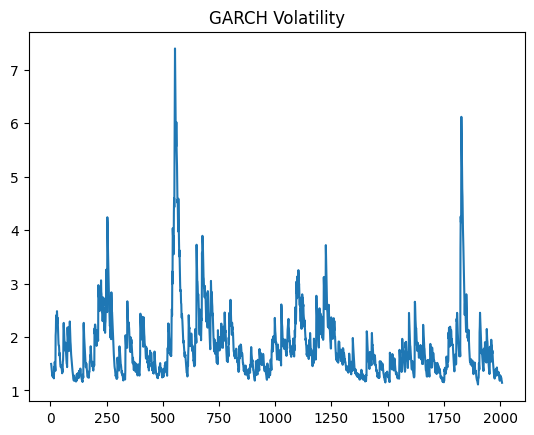

In [ ]:
garch = arch_model(data['Returns']*100, vol='Garch', p=1, q=1)
fit = garch.fit(disp='off')

plt.figure()
plt.plot(fit.conditional_volatility)
plt.title("GARCH Volatility")
plt.savefig("figures/figure_4_garch_volatility.png") # Save the figure
plt.show()

**Figure 4:** Estimated conditional volatility showing clustering over time.

### Interpretation
The GARCH volatility plot visually confirms the presence of volatility clustering in the AAPL stock returns. Peaks in the plot correspond to periods of high market uncertainty and large price swings, while troughs indicate periods of relative calm and stable prices. The time-varying nature of this estimated conditional volatility clearly demonstrates that assuming constant volatility would be inappropriate and misleading for this financial series. The GARCH model successfully captures how volatility ebbs and flows over time, reflecting actual market conditions.

### Importance
Accurate modeling of volatility is paramount in finance for several reasons:
*   **Risk Management**: It allows for better estimation of Value at Risk (VaR) and other risk measures, leading to more robust risk management strategies.
*   **Asset Pricing**: Option pricing models (e.g., Black-Scholes) rely on volatility estimates. GARCH-based volatilities can improve the accuracy of these prices.
*   **Portfolio Management**: Understanding and forecasting volatility helps in optimal portfolio allocation, hedging strategies, and dynamic asset allocation decisions.
*   **Forecasting**: GARCH models provide more accurate forecasts of future volatility, which is a key input for many financial decisions.

By explicitly modeling volatility, financial practitioners can make more informed decisions, leading to improved risk management, more precise asset valuations, and ultimately, better financial outcomes.

## Conclusion

This study clearly shows that financial data, especially Apple Inc. (AAPL) stock returns, doesn't always fit the rules of standard statistical models. By looking closely at data from 2018–2025, we found several key challenges in understanding financial data.

Our findings clearly confirm:

*   **Multicollinearity**: Although not a big problem in our simple model with lagged returns, it can make it hard to understand what each variable does and can make errors seem bigger in more complex models.
*   **Skewness**: The slight negative skewness we saw means that very bad returns can happen more often or be more severe than very good ones. Not considering this can lead to underestimating risks.
*   **Outliers**: Many extreme data points were found, showing how big market events can mess up statistical estimates and model settings if not handled correctly.
*   **Overfitting**: Using a simple linear regression example, we highlighted how important it is to keep models from being too complex. While our simple model didn't overfit, we explained that overfitting can make models bad at predicting new data, leading to big financial losses.
*   **Volatility Clustering**: The GARCH model successfully showed that volatility changes over time, meaning it's not constant. This means we need special models to properly assess and predict risk.

### Final Insight

Because these statistical challenges are so common in financial data, we need to use strong and advanced methods. Our analysis shows that methods like GARCH modeling for changing volatility, along with careful use of techniques to prevent overfitting and robust statistical approaches for other issues, are vital for building reliable and accurate financial models. Ignoring these common features of financial data can lead to wrong estimates, bad forecasts, and major financial losses (Tsay; Brooks).

## References

### Data Source
Yahoo Finance. “Apple Inc. (AAPL) Historical Data.” Yahoo Finance, https://finance.yahoo.com/quote/AAPL/history/.

### Core Econometrics & Regression
Wooldridge, Jeffrey M. *Introductory Econometrics: A Modern Approach*. 5th ed., Cengage Learning, 2015.  

Gujarati, Damodar N., and Dawn C. Porter. *Basic Econometrics*. 5th ed., McGraw-Hill, 2009.  

Stock, James H., and Mark W. Watson. *Introduction to Econometrics*. 3rd ed., Pearson, 2011.  

---

### Financial Time Series & Volatility
 *Analysis of Financial Time Series*. 3rd ed., Wiley, 2010.  

 “Generalized Autoregressive Conditional Heteroskedasticity.” *Journal of Econometrics*, vol. 31, no. 3, 1986, pp. 307–327.  

 “Autoregressive Conditional Heteroskedasticity with Estimates of the Variance of UK Inflation.” *Econometrica*, 1982.  

---

### Statistical Concepts (Skewness, Outliers, Diagnostics)
 *Discovering Statistics Using IBM SPSS Statistics*. Sage, 2013.  

 *Applied Regression Analysis and Generalized Linear Models*. Sage, 2015.  

---

### Machine Learning & Overfitting
. *The Elements of Statistical Learning*. Springer, 2009.  

 *An Introduction to Statistical Learning*. Springer, 2013.  

---

### Python & Data Tools
 Documentation. https://pypi.org/project/yfinance/  

 Documentation. https://pandas.pydata.org/  

 Documentation. https://scikit-learn.org/  

 Documentation. https://www.statsmodels.org/  

 Documentation. https://arch.readthedocs.io/  

---

### Additional Supporting Sources
Brooks, Chris. *Introductory Econometrics for Finance*. Cambridge University Press, 2014.  

Hamilton, James D. *Time Series Analysis*. Princeton University Press, 1994.

Hastie, Trevor, Robert Tibshirani, and Jerome Friedman. The Elements of Statistical Learning. Springer, 2009.